# Hotel Bar Inventory Forecasting & Par Level Recommendation
EDA -> daily demand forecasting -> par levels -> inventory backtest.
**Assumptions:** lead time L = 2 days; unmet demand is lost (not backordered); a bar-brand-day with no transaction = zero consumption; units in ml.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from src.data_validation import check_conservation, build_daily_panel
from src.forecasting import wape, mae, rmse, holt_winters_one_step
from src.inventory_optimization import safety_stock
from src.simulation import simulate_inventory
sns.set_theme(style='whitegrid'); pd.options.display.float_format = '{:,.3f}'.format
L, Z95, Z99 = 2, 1.645, 2.326

## 1. Load, validate, aggregate to a dense daily panel

In [2]:
raw = pd.read_csv('../data/raw/bar_inventory_data.csv')
raw['Date Time Served'] = pd.to_datetime(raw['Date Time Served'], format='%m/%d/%Y %H:%M')
raw.columns = [c.replace(' (ml)', '') for c in raw.columns]
bad = check_conservation(raw, 'Opening Balance', 'Purchase', 'Consumed', 'Closing Balance')
raw['date'] = raw['Date Time Served'].dt.floor('D')
print(f'rows={len(raw):,}  conservation violations={bad.sum()}  bars={raw["Bar Name"].nunique()}  brands={raw["Brand Name"].nunique()}  '
      f'span={raw.date.min().date()}..{raw.date.max().date()}')
keys = ['Bar Name', 'Brand Name']
daily = raw.groupby(['date'] + keys, as_index=False).agg(consumption=('Consumed', 'sum'))
panel = build_daily_panel(daily, keys).sort_values(keys + ['date']).reset_index(drop=True)
print(f'panel rows={len(panel):,} (= days x series)  zero-demand share={(panel.consumption == 0).mean():.1%}')
panel.rename(columns={'date': 'Date', 'consumption': 'Consumed (ml)'}).to_csv('../data/processed/daily_bar_consumption.csv', index=False)

rows=6,575  conservation violations=145  bars=6  brands=16  span=2023-01-01..2024-01-01
panel rows=35,136 (= days x series)  zero-demand share=83.9%


## 2. EDA: ABC velocity, day-of-week pattern, stockout audit

abc
A    69
B    19
C     8


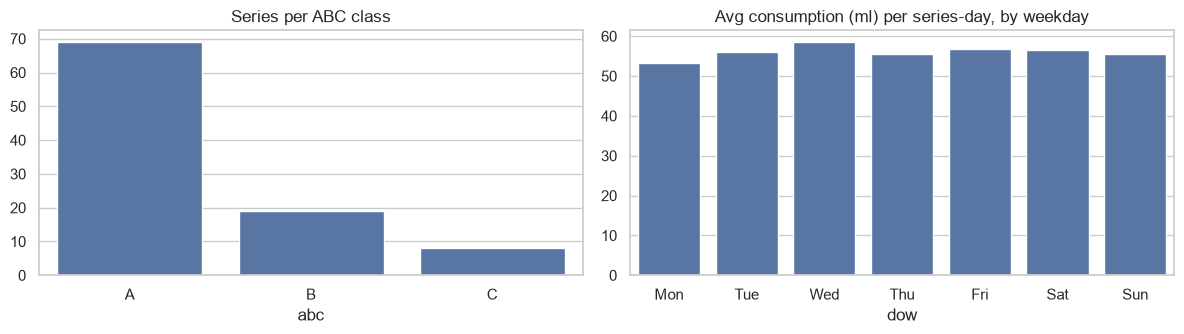

In [3]:
vol = panel.groupby(keys).consumption.sum().sort_values(ascending=False).to_frame('total_ml')
vol['cum_share'] = vol.total_ml.cumsum() / vol.total_ml.sum()
vol['abc'] = np.where(vol.cum_share <= 0.80, 'A', np.where(vol.cum_share <= 0.95, 'B', 'C'))
print(vol.abc.value_counts().sort_index().to_string())
dow = panel.assign(dow=panel.date.dt.day_name()).groupby('dow').consumption.mean()
dow = dow.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
sns.barplot(x=vol.abc.value_counts().sort_index().index, y=vol.abc.value_counts().sort_index().values, ax=ax[0]); ax[0].set_title('Series per ABC class')
sns.barplot(x=dow.index.str[:3], y=dow.values, ax=ax[1]); ax[1].set_title('Avg consumption (ml) per series-day, by weekday')
plt.tight_layout(); plt.show()

In [4]:
# Stockout audit: closing balance == 0 on a series that has non-zero demand historically
active = vol.index[vol.total_ml > 0]
so = raw[(raw['Closing Balance'] == 0)].set_index(keys).loc[lambda d: d.index.isin(active)]
print(f'historical stockout rows (closing==0, item has demand): {len(so)} of {len(raw)} ({len(so)/len(raw):.1%})')
print(so.groupby(level=0).size().sort_values(ascending=False).to_string())

historical stockout rows (closing==0, item has demand): 416 of 6575 (6.3%)
Bar Name
Thomas's Bar      103
Taylor's Bar       94
Brown's Bar        78
Anderson's Bar     73
Smith's Bar        37
Johnson's Bar      31


## 3. Demand forecasting
Temporal split: first 80% of days = train, last 20% = test (no shuffling). All models produce **one-step-ahead** predictions on the test window.
Models: 7-day rolling mean, seasonal naive (t-7), Holt-Winters (params fit on train only), pooled RandomForest (lags 1/7/14, 7-day rolling mean/std, weekday, series id).

In [5]:
dates = np.sort(panel.date.unique()); cut = dates[int(len(dates) * 0.8)]
print('test starts', str(cut)[:10], '| train days', (dates < cut).sum(), '| test days', (dates >= cut).sum())
g = panel.groupby(keys).consumption
panel['roll7'] = g.transform(lambda s: s.shift(1).rolling(7, min_periods=1).mean()).fillna(0)
panel['snaive'] = g.shift(7).fillna(0)
hw = []
for _, idx in panel.groupby(keys).groups.items():
    s = panel.loc[idx, 'consumption']; hw.append(pd.Series(holt_winters_one_step(s[panel.loc[idx, 'date'] < cut], s), index=idx))
panel['hw'] = pd.concat(hw)

test starts 2023-10-20 | train days 292 | test days 74


                       WAPE    MAE    RMSE
Rolling mean (7d)     1.663 92.624 153.197
Seasonal naive (t-7)  1.751 97.527 203.597
Holt-Winters          1.683 93.746 145.593
RandomForest (pooled) 1.724 96.059 147.070
best by WAPE: Rolling mean (7d)


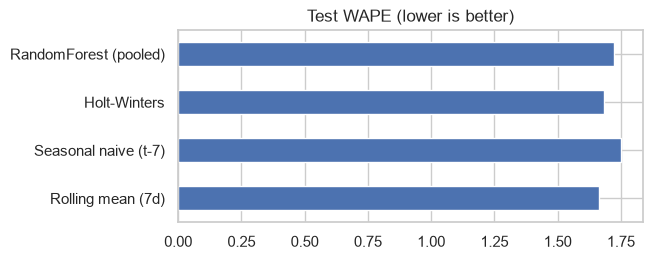

In [6]:
panel['series'] = panel.groupby(keys).ngroup()
for k in (1, 7, 14): panel[f'lag_{k}'] = g.shift(k)
panel['rm7'] = g.transform(lambda s: s.shift(1).rolling(7).mean()); panel['rs7'] = g.transform(lambda s: s.shift(1).rolling(7).std())
panel['dow'] = panel.date.dt.dayofweek; panel['is_weekend'] = panel.dow.isin([4, 5, 6]).astype(int)
feats = ['lag_1', 'lag_7', 'lag_14', 'rm7', 'rs7', 'dow', 'is_weekend', 'series']
tr = panel[(panel.date < cut)].dropna(subset=feats)
rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=0).fit(tr[feats], tr.consumption)
test = panel[panel.date >= cut].copy()
test['rf'] = np.clip(rf.predict(test[feats].fillna(0)), 0, None)
models = {'Rolling mean (7d)': 'roll7', 'Seasonal naive (t-7)': 'snaive', 'Holt-Winters': 'hw', 'RandomForest (pooled)': 'rf'}
res = pd.DataFrame({n: {'WAPE': wape(test.consumption, test[c]), 'MAE': mae(test.consumption, test[c]), 'RMSE': rmse(test.consumption, test[c])} for n, c in models.items()}).T
print(res.to_string()); best = res.WAPE.idxmin(); bc = models[best]; print('best by WAPE:', best)
res.WAPE.plot.barh(title='Test WAPE (lower is better)', figsize=(6, 2.5)); plt.show()

## 4. Par levels
Par = L x forecast daily demand + Z x sigma x sqrt(L). sigma = std of the 7-day rolling-mean baseline's **training-period** errors per series (ex-ante, no test leakage). Par is recomputed each day from the best model's forecast (dynamic).

In [7]:
trn = panel[panel.date < cut]
sigma = (trn.consumption - trn.roll7).groupby([trn['Bar Name'], trn['Brand Name']]).std().fillna(0).rename('sigma')
test = test.join(sigma, on=keys)
for z, tag in ((Z95, 'par95'), (Z99, 'par99')):
    test[tag] = L * test[bc] + test.apply(lambda r: safety_stock(r.sigma, L, {Z95: .95, Z99: .99}[z]), axis=1)
latest = test[test.date == test.date.max()].set_index(keys)[['sigma', bc, 'par95', 'par99']].rename(columns={bc: 'forecast_daily_ml'})
latest.to_csv('../reports/par_levels.csv'); latest.sort_values('par95', ascending=False).head(10)

sigma  forecast_daily_ml   par95     par99
Bar Name       Brand Name                                               
Anderson's Bar Bacardi      172.124            256.521 913.433 1,079.322
Smith's Bar    Malibu       168.419            208.051 807.874   970.193
Johnson's Bar  Grey Goose   165.531            169.431 723.917   883.452
Thomas's Bar   Grey Goose   170.395            157.556 711.480   875.702
Taylor's Bar   Malibu       156.533            168.363 700.849   851.712
               Smirnoff     149.581            172.906 693.763   837.927
Anderson's Bar Jim Beam     160.220            158.483 689.666   844.083
Smith's Bar    Grey Goose   171.607            134.710 668.609   834.000
Brown's Bar    Malibu       142.264            166.779 664.488   801.600
Johnson's Bar  Jack Daniels 155.480            127.199 616.071   765.920

## 5. Inventory simulation backtest (test window, lead time 2 days, order-up-to policy)
Compared: **static baseline** = train mean daily demand x L (no safety stock) vs **dynamic par** at 95% and 99% service.

                            stockout_days     lost_ml  fill_rate  avg_inventory_ml (sum of series)  turnover
policy                                                                                                      
Static baseline (mean x L)           1086 284,593.860      0.281                         7,791.066    14.269
Dynamic par 95%                       292  48,575.193      0.877                        42,372.430     8.194
Dynamic par 99%                       139  23,366.314      0.941                        55,702.746     6.685


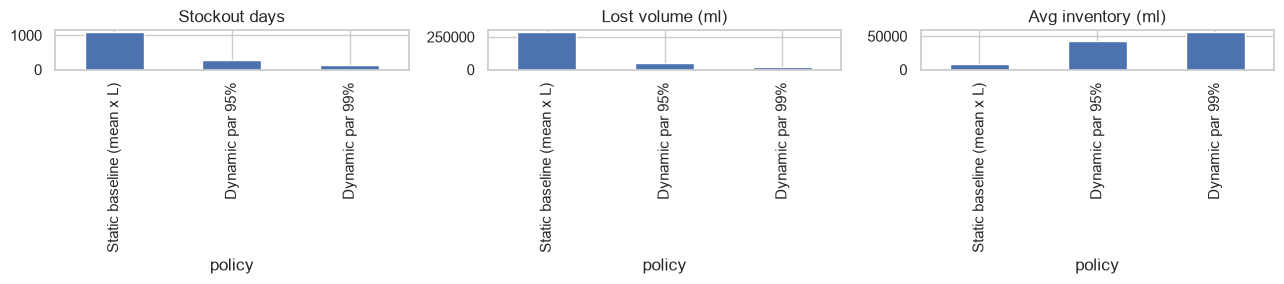

In [8]:
train_mean = trn.groupby(keys).consumption.mean()
rows = []
for name in ('Static baseline (mean x L)', 'Dynamic par 95%', 'Dynamic par 99%'):
    tot = dict(stockout_days=0, lost_ml=0.0, avg_inv=0.0, served=0.0, demand=0.0)
    for k, s in test.groupby(keys):
        par = np.full(len(s), train_mean[k] * L) if name.startswith('Static') else s['par95' if '95' in name else 'par99'].to_numpy()
        r = simulate_inventory(s.consumption.to_numpy(), par[0], par, L)
        tot['stockout_days'] += r.stockout_days; tot['lost_ml'] += r.lost_units; tot['avg_inv'] += r.average_inventory
        tot['served'] += s.consumption.sum() - r.lost_units; tot['demand'] += s.consumption.sum()
    rows.append({'policy': name, 'stockout_days': tot['stockout_days'], 'lost_ml': tot['lost_ml'], 'fill_rate': tot['served'] / tot['demand'],
                 'avg_inventory_ml (sum of series)': tot['avg_inv'], 'turnover': tot['served'] / tot['avg_inv']})
sim = pd.DataFrame(rows).set_index('policy'); print(sim.to_string())
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
sim.stockout_days.plot.bar(ax=ax[0], title='Stockout days'); sim.lost_ml.plot.bar(ax=ax[1], title='Lost volume (ml)'); sim.iloc[:, 3].plot.bar(ax=ax[2], title='Avg inventory (ml)')
plt.tight_layout(); plt.show()

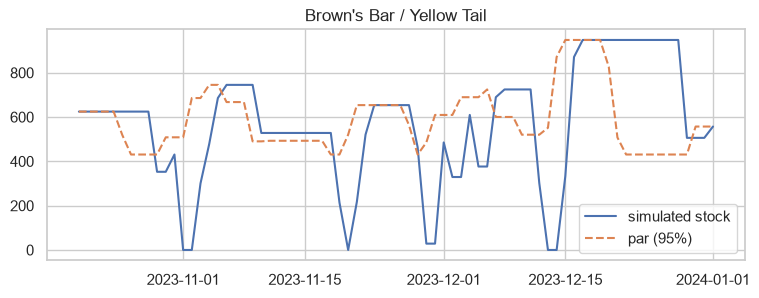

In [9]:
# Illustration: stock vs dynamic par for the highest-volume series
k = vol.index[0]; s = test[(test['Bar Name'] == k[0]) & (test['Brand Name'] == k[1])]
par = s.par95.to_numpy(); inv, pending, stock = par[0], [], []
for d, dem in enumerate(s.consumption.to_numpy()):
    inv += sum(q for t, q in pending if t <= d); pending = [(t, q) for t, q in pending if t > d]
    inv -= min(inv, dem); pos = inv + sum(q for _, q in pending)
    if pos < par[d]: pending.append((d + L, par[d] - pos))
    stock.append(inv)
plt.figure(figsize=(9, 3)); plt.plot(s.date, stock, label='simulated stock'); plt.plot(s.date, par, '--', label='par (95%)')
plt.title(f'{k[0]} / {k[1]}'); plt.legend(); plt.show()

## 6. Conclusions
See `sim` and `res` above; the numbers are quoted in `reports/business_report.md`.